# 🔬 양자컴퓨팅 기초 실습 (Qiskit)

이 노트북은 양자컴퓨팅의 핵심 개념을 단계별로 배우고 직접 실행해보는 hands-on 실습 자료입니다.

## 📚 목차

| # | 섹션 | 핵심 개념 |
|---|------|----------|
| 1 | 환경 설정 | Qiskit 설치 및 임포트 |
| 2 | 기초 게이트 | X, H, Z, Y, S, T, CNOT, Toffoli |
| 3 | 블로흐 구면 시각화 | 단일 큐비트 상태 |
| 4 | 벨 상태 (Bell States) | 양자 얽힘의 기초 |
| 5 | 양자 텔레포테이션 | 얽힘 응용 |
| 6 | Deutsch–Jozsa 알고리즘 | 오라클 양자우위 |
| 7 | Bernstein-Vazirani 알고리즘 | 비밀 문자열 탐색 |




## 1. 환경 설정

In [1]:
# 필요한 패키지 설치 (최초 1회)
# !pip install qiskit qiskit-aer matplotlib pylatexenc -q


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# 상태벡터 & 밀도행렬
from qiskit.quantum_info import Statevector, DensityMatrix

# 시각화
from qiskit.visualization import plot_histogram, plot_bloch_multivector

# 시뮬레이터 초기화
sim = AerSimulator()
sim_sv = AerSimulator(method='statevector')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})
print("✅ Qiskit", __import__('qiskit').__version__, "준비 완료!")


✅ Qiskit 2.4.1 준비 완료!


## 2. 기초 양자 게이트

양자 게이트는 고전 컴퓨터의 논리 게이트에 대응됩니다.
단, **가역적(reversible)** 이며 **유니터리 행렬**로 표현됩니다.

### 주요 단일 큐비트 게이트

| 게이트 | 행렬 | 효과 |
|--------|------|------|
| **I** | [[1,0],[0,1]] | 항등 (아무것도 안 함) |
| **X** (NOT) | [[0,1],[1,0]] | ∣0⟩↔∣1⟩ 반전 |
| **H** (Hadamard) | 1/√2 [[1,1],[1,-1]] | 중첩 상태 생성 |
| **Z** | [[1,0],[0,-1]] | 위상 반전 (∣1⟩에 -1) |
| **Y** | [[0,-i],[i,0]] | X+Z 조합 |
| **S** | [[1,0],[0,i]] | 위상 π/2 |
| **T** | [[1,0],[0,e^iπ/4]] | 위상 π/4 |
| **Rx/Ry/Rz(θ)** | 회전 행렬 | 임의 회전 |

### 다중 큐비트 게이트

| 게이트 | 큐비트 수 | 효과 |
|--------|----------|------|
| **CNOT (CX)** | 2 | 제어 큐비트가 ∣1⟩일 때 타겟 반전 |
| **CZ** | 2 | 제어 큐비트가 ∣1⟩일 때 타겟 위상 반전 |
| **SWAP** | 2 | 두 큐비트 교환 |
| **Toffoli (CCX)** | 3 | CCNOT: 양자 AND 게이트 |
| **CSWAP (Fredkin)** | 3 | 제어 SWAP |


게이트 수: OrderedDict({'barrier': 2, 'x': 1, 'h': 1, 'z': 1, 'y': 1, 's': 1, 't': 1, 'sdg': 1, 'tdg': 1, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 1, 'cz': 1, 'swap': 1, 'ccx': 1, 'cswap': 1, 'cp': 1, 'cu': 1})


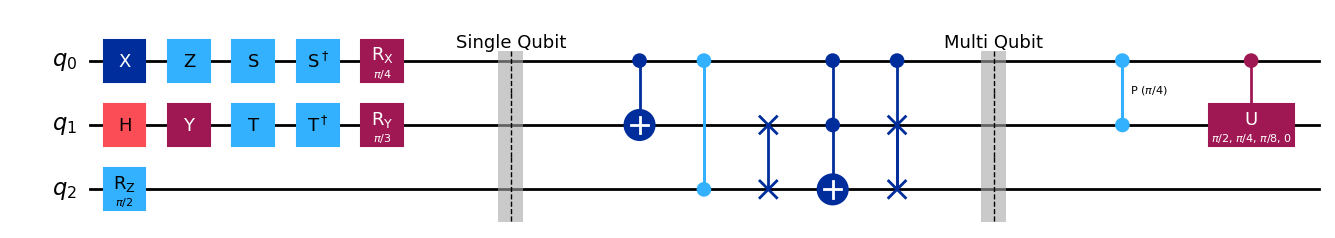

In [3]:
# ── 2-A. 모든 기초 게이트를 한 회로에 ──────────────────────────────────
qc = QuantumCircuit(3, name="기초 게이트 모음")

# 단일 큐비트 게이트
qc.x(0)          # Pauli-X (NOT)
qc.h(1)          # Hadamard → 중첩
qc.z(0)          # Pauli-Z
qc.y(1)          # Pauli-Y
qc.s(0)          # S 게이트 (π/2 위상)
qc.t(1)          # T 게이트 (π/4 위상)
qc.sdg(0)        # S† (S의 역)
qc.tdg(1)        # T† (T의 역)
qc.rx(np.pi/4, 0)  # X축 π/4 회전
qc.ry(np.pi/3, 1)  # Y축 π/3 회전
qc.rz(np.pi/2, 2)  # Z축 π/2 회전

qc.barrier(label="Single Qubit")

# 다중 큐비트 게이트
qc.cx(0, 1)      # CNOT
qc.cz(0, 2)      # CZ
qc.swap(1, 2)    # SWAP
qc.ccx(0, 1, 2)  # Toffoli (CCX)
qc.cswap(0, 1, 2) # CSWAP (Fredkin)

qc.barrier(label="Multi Qubit")

# 제어 위상 게이트
qc.cp(np.pi/4, 0, 1)   # 제어 위상
qc.cu(np.pi/2, np.pi/4, np.pi/8, 0, 0, 1)  # 제어 U

print("게이트 수:", qc.count_ops())
qc.draw('mpl', style='iqp', fold=30)


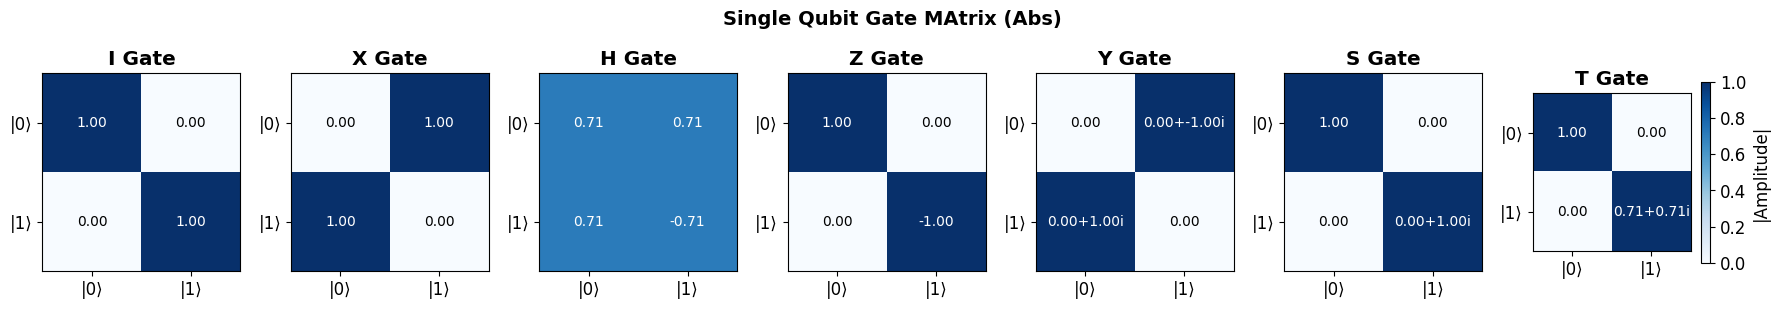

In [4]:
# ── 2-B. 게이트 행렬 시각화 ────────────────────────────────────────────
from qiskit.quantum_info import Operator

gates_info = {
    'I': QuantumCircuit(1),
    'X': QuantumCircuit(1),
    'H': QuantumCircuit(1),
    'Z': QuantumCircuit(1),
    'Y': QuantumCircuit(1),
    'S': QuantumCircuit(1),
    'T': QuantumCircuit(1),
}
gates_info['X'].x(0)
gates_info['H'].h(0)
gates_info['Z'].z(0)
gates_info['Y'].y(0)
gates_info['S'].s(0)
gates_info['T'].t(0)

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
for ax, (name, qc_g) in zip(axes, gates_info.items()):
    mat = Operator(qc_g).data
    im = ax.imshow(np.abs(mat), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} Gate', fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['|0⟩','|1⟩']); ax.set_yticklabels(['|0⟩','|1⟩'])
    for i in range(2):
        for j in range(2):
            val = mat[i, j]
            ax.text(j, i, f'{val.real:.2f}{"" if abs(val.imag)<0.01 else f"+{val.imag:.2f}i"}',
                    ha='center', va='center', fontsize=10,
                    color='white' if abs(val) > 0.5 else 'black')
plt.colorbar(im, ax=axes[-1], shrink=0.8, label='|Amplitude|')
plt.suptitle("Single Qubit Gate MAtrix (Abs)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. 블로흐 구면 (Bloch Sphere) 시각화

단일 큐비트 상태 |ψ⟩ = α|0⟩ + β|1⟩ 는 블로흐 구면 위의 한 점으로 표현됩니다.

```
|ψ⟩ = cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩
```

- **북극 (0,0,+1)** → |0⟩
- **남극 (0,0,-1)** → |1⟩  
- **+X 축** → |+⟩ = (|0⟩+|1⟩)/√2  ← Hadamard 적용 결과
- **-X 축** → |−⟩ = (|0⟩−|1⟩)/√2


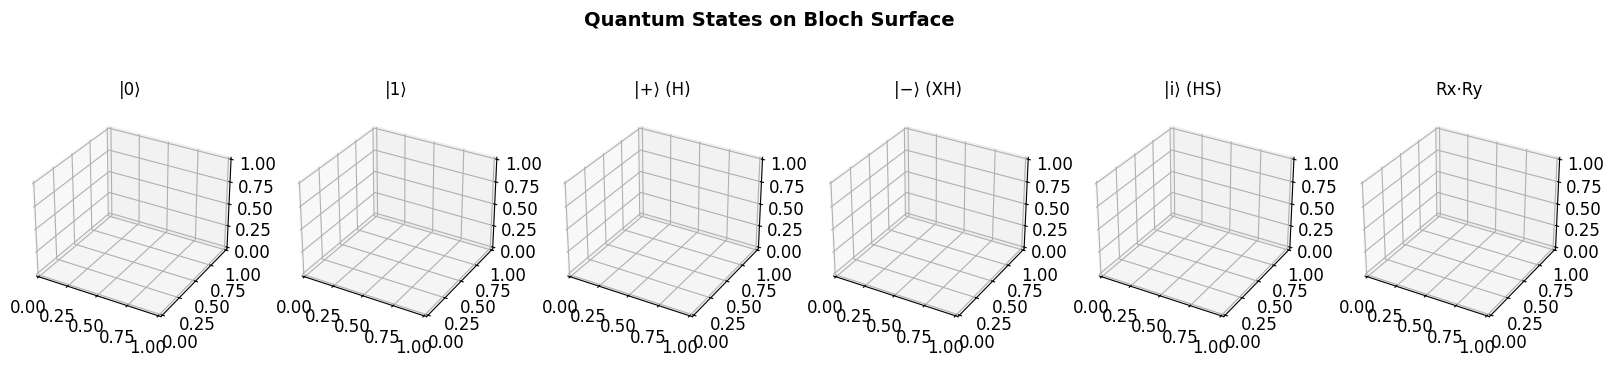

In [5]:
# ── 3-A. 주요 상태의 블로흐 구면 ─────────────────────────────────────
states = {}

# |0⟩ (기저 상태)
qc0 = QuantumCircuit(1)
states['|0⟩'] = Statevector(qc0)

# |1⟩ (X 게이트)
qc1 = QuantumCircuit(1); qc1.x(0)
states['|1⟩'] = Statevector(qc1)

# |+⟩ (Hadamard)
qcP = QuantumCircuit(1); qcP.h(0)
states['|+⟩ (H)'] = Statevector(qcP)

# |−⟩ (X then H)
qcM = QuantumCircuit(1); qcM.x(0); qcM.h(0)
states['|−⟩ (XH)'] = Statevector(qcM)

# |i⟩ (H then S)
qcI = QuantumCircuit(1); qcI.h(0); qcI.s(0)
states['|i⟩ (HS)'] = Statevector(qcI)

# 임의 회전
qcR = QuantumCircuit(1); qcR.rx(np.pi/3, 0); qcR.ry(np.pi/4, 0)
states['Rx·Ry'] = Statevector(qcR)

fig, axes = plt.subplots(1, 6, figsize=(20, 4),
                          subplot_kw={'projection': '3d'})
plt.suptitle("Quantum States on Bloch Surface", fontsize=14, fontweight='bold', y=1.02)

for ax, (label, sv) in zip(axes, states.items()):
    fig_tmp = plot_bloch_multivector(sv)
    # 블로흐 구면 그림을 개별 axes에 그리기
    ax.set_title(label, fontsize=12, pad=10)
    plt.close(fig_tmp)

# plot_bloch_multivector로 직접 그리기
for i, (label, sv) in enumerate(states.items()):
    fig_b = plot_bloch_multivector(sv, title=label, figsize=(3, 3))
    plt.show()
    plt.close()


In [6]:
# ── 3-B. 게이트 적용에 따른 상태 변화 ─────────────────────────────────
print("📍 단일 큐비트 게이트 적용 순서에 따른 상태 변화\n")

steps = [
    ("|0⟩ 초기 상태", QuantumCircuit(1)),
]

qc_step = QuantumCircuit(1)
qc_step.h(0)
steps.append(("|+⟩ = H|0⟩", qc_step.copy()))

qc_step.z(0)
steps.append(("Z|+⟩ = |−⟩", qc_step.copy()))

qc_step.h(0)
steps.append(("H|−⟩ = |1⟩", qc_step.copy()))

qc_step.s(0)
steps.append(("S|1⟩", qc_step.copy()))

for label, qc_s in steps:
    sv = Statevector(qc_s)
    probs = sv.probabilities_dict()
    print(f"  {label:15s} → 상태벡터 = {np.round(sv.data, 3)}")
    print(f"  {'':15s}   측정 확률 = {probs}\n")


📍 단일 큐비트 게이트 적용 순서에 따른 상태 변화

  |0⟩ 초기 상태       → 상태벡터 = [1.+0.j 0.+0.j]
                    측정 확률 = {np.str_('0'): np.float64(1.0)}

  |+⟩ = H|0⟩      → 상태벡터 = [0.707+0.j 0.707+0.j]
                    측정 확률 = {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}

  Z|+⟩ = |−⟩      → 상태벡터 = [ 0.707+0.j -0.707+0.j]
                    측정 확률 = {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}

  H|−⟩ = |1⟩      → 상태벡터 = [0.+0.j 1.+0.j]
                    측정 확률 = {np.str_('1'): np.float64(0.9999999999999996)}

  S|1⟩            → 상태벡터 = [0.+0.j 0.+1.j]
                    측정 확률 = {np.str_('1'): np.float64(0.9999999999999996)}



## 4. 벨 상태 (Bell States) — 2큐비트 최대 얽힘

4가지 벨 상태는 2큐비트 힐베르트 공간의 직교 정규 기저입니다:

| 상태 | 수식 | 의미 |
|------|------|------|
| **Φ⁺** | (∣00⟩ + ∣11⟩)/√2 | H + CNOT |
| **Φ⁻** | (∣00⟩ − ∣11⟩)/√2 | Z 위상 적용 |
| **Ψ⁺** | (∣01⟩ + ∣10⟩)/√2 | X 적용 후 |
| **Ψ⁻** | (∣01⟩ − ∣10⟩)/√2 | 싱글렛 상태 |

> **얽힘(Entanglement)**: 두 큐비트를 분리된 상태의 텐서곱으로 나타낼 수 없음 → EPR 쌍


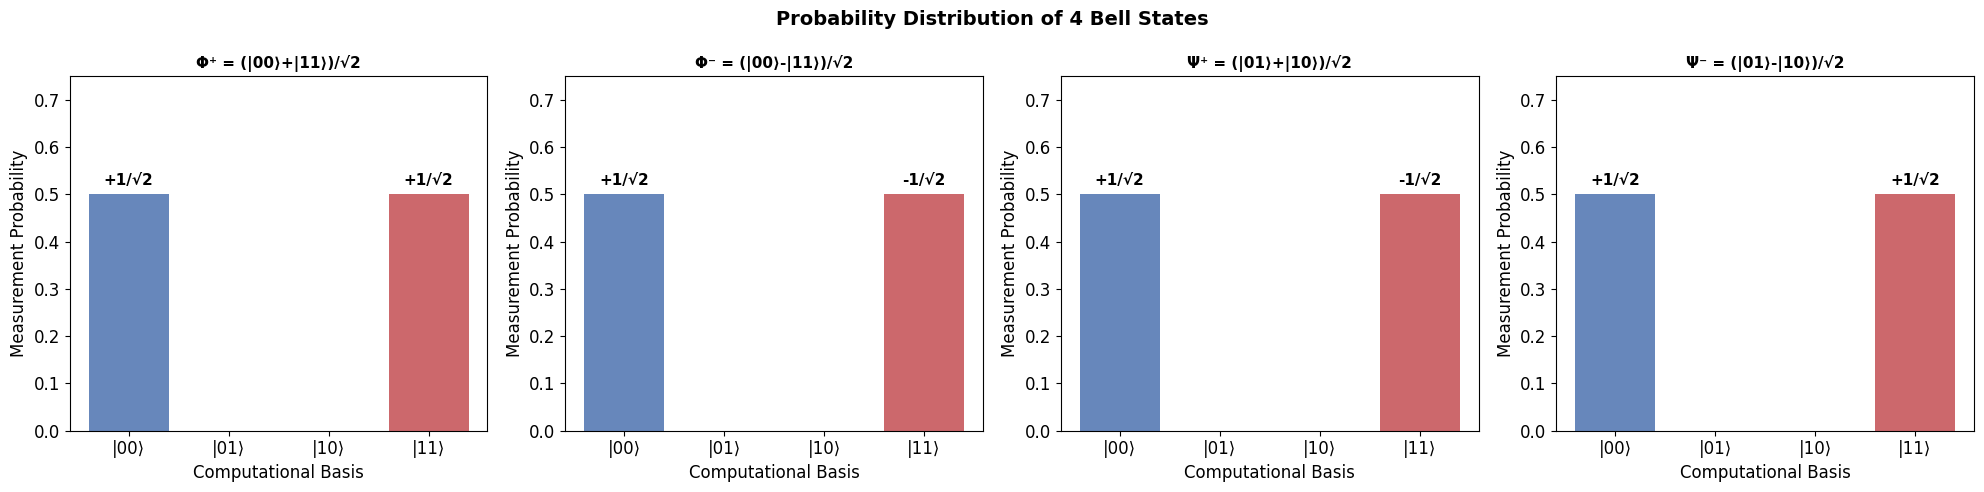

In [7]:
# ── 4-A. 4가지 벨 상태 생성 ────────────────────────────────────────────
def make_bell(phi_plus=True, psi=False):
    """벨 상태 생성기"""
    qc = QuantumCircuit(2)
    if psi:   qc.x(0)           # Ψ: 첫 큐비트 반전
    qc.h(0)                     # 중첩
    qc.cx(0, 1)                 # 얽힘
    if not phi_plus: qc.z(0)   # Φ⁻ / Ψ⁻: 위상 반전
    return qc

bell_states = {
    'Φ⁺ = (|00⟩+|11⟩)/√2': make_bell(phi_plus=True,  psi=False),
    'Φ⁻ = (|00⟩-|11⟩)/√2': make_bell(phi_plus=False, psi=False),
    'Ψ⁺ = (|01⟩+|10⟩)/√2': make_bell(phi_plus=True,  psi=True),
    'Ψ⁻ = (|01⟩-|10⟩)/√2': make_bell(phi_plus=False, psi=True),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, qc_b) in zip(axes, bell_states.items()):
    sv = Statevector(qc_b)
    probs = {k: v for k, v in sv.probabilities_dict().items() if v > 0.01}
    amplitudes = {k: sv.data[int(k,2)] for k in ['00','01','10','11']}
    
    bars = ax.bar(['|00⟩','|01⟩','|10⟩','|11⟩'],
                  [abs(amplitudes[k])**2 for k in ['00','01','10','11']],
                  color=['#4C72B0','#DD8452','#55A868','#C44E52'], alpha=0.85)
    for bar, k in zip(bars, ['00','01','10','11']):
        amp = amplitudes[k]
        if abs(amp) > 0.01:
            sign = '+' if amp.real > 0 else '-'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{sign}1/√2', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 0.75)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Measurement Probability')
    ax.set_xlabel('Computational Basis')

plt.suptitle("Probability Distribution of 4 Bell States", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Φ⁺ 벨 상태 회로
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


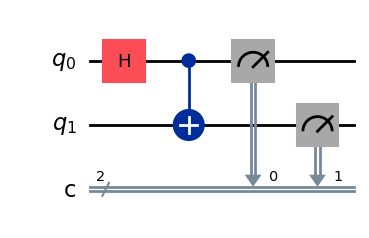


측정 결과 (2048회): {'00': 988, '11': 1060}
→ |00⟩ 과 |11⟩ 만 나타남 = 완벽한 얽힘!


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/qiskit/visualization/counts_visualization.py:412: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/qiskit/visualization/counts_visualization.py:412: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/qiskit/visualization/counts_visualization.py:412: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/qiskit/visualization/counts_visualization.py:412: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/qiskit/visualization/counts_visualization.py

In [8]:
# ── 4-B. 벨 회로 시각화 & 시뮬레이션 ──────────────────────────────────
qc_phi_plus = QuantumCircuit(2, 2)
qc_phi_plus.h(0)
qc_phi_plus.cx(0, 1)
qc_phi_plus.measure([0,1],[0,1])

print("━" * 40)
print("  Φ⁺ 벨 상태 회로")
print("━" * 40)
display(qc_phi_plus.draw('mpl', style='iqp'))

result = sim.run(transpile(qc_phi_plus, sim), shots=2048).result()
counts = result.get_counts()
print(f"\n측정 결과 (2048회): {counts}")
print("→ |00⟩ 과 |11⟩ 만 나타남 = 완벽한 얽힘!")
plot_histogram(counts, title="Φ⁺ 벨 상태 측정 분포", figsize=(6,4), color='#4C72B0')
plt.show()


## 5. 양자 텔레포테이션 (Quantum Teleportation)

앨리스(Alice)가 임의의 양자 상태 |ψ⟩ = α|0⟩ + β|1⟩를 
물리적 입자 이동 없이 밥(Bob)에게 전송합니다.

### 프로토콜 단계

```
앨리스 측:                      밥 측:
q0: |ψ⟩ ─────────────          
                        [벨 쌍 공유]
q1: |0⟩ ──[H]──[CNOT]──────── q2: |0⟩
                 ↓ CNOT                ↓ (고전 채널로 2비트 전송)
q0 ─── H ─── 측정 ──────────────── X? Z?
q1 ───────── 측정 ──────────────── |ψ⟩ ✓
```

**핵심**: 고전 정보 2비트로 양자 상태 완벽 복원  
(하지만 초광속 통신은 불가: 밥은 고전 비트 없이는 알 수 없음)


양자 텔레포테이션 회로:


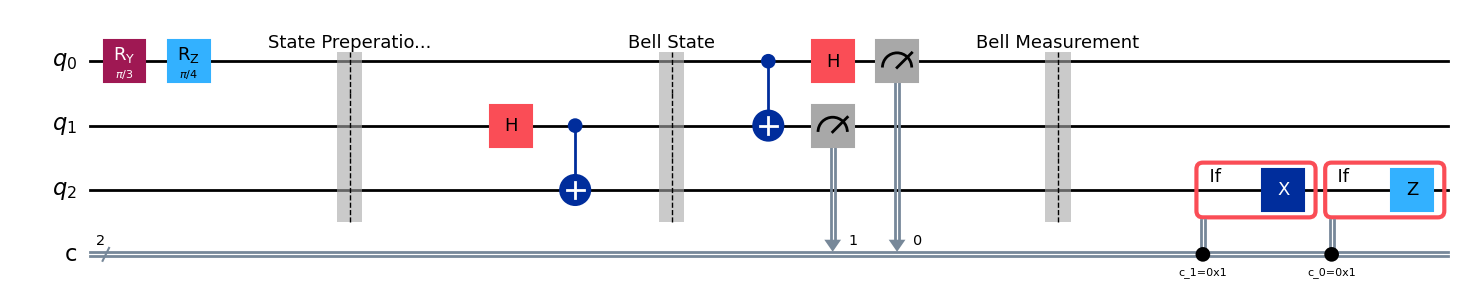


원본 상태 |ψ⟩ = [0.8001-0.3314j 0.4619+0.1913j]
  |0⟩ 확률: 0.7500
  |1⟩ 확률: 0.2500


In [9]:
# ── 5-A. 양자 텔레포테이션 회로 ─────────────────────────────────────────
def teleportation_circuit(theta=np.pi/3, phi=np.pi/4):
    """
    q0: 전송할 상태 |ψ⟩ = Ry(θ)Rz(φ)|0⟩  (앨리스)
    q1: 벨 쌍의 앨리스 절반
    q2: 벨 쌍의 밥 절반
    """
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr, name="텔레포테이션")

    # 1. 전송할 상태 준비
    qc.ry(theta, 0)
    qc.rz(phi, 0)
    qc.barrier(label="State Preperation")

    # 2. 벨 쌍 생성 (q1-q2 사이)
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier(label="Bell State")

    # 3. 앨리스의 벨 측정
    qc.cx(0, 1)
    qc.h(0)
    qc.measure([0, 1], [0, 1])
    qc.barrier(label="Bell Measurement")

    # 4. 밥의 수정 (고전 비트 기반, if_test 사용)
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)    # c1==1 이면 X 게이트
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)    # c0==1 이면 Z 게이트

    return qc, theta, phi

qc_tele, theta, phi = teleportation_circuit(np.pi/3, np.pi/4)
print("양자 텔레포테이션 회로:")
display(qc_tele.draw('mpl', style='iqp', fold=50))

# 원본 상태 계산
qc_orig = QuantumCircuit(1)
qc_orig.ry(theta, 0)
qc_orig.rz(phi, 0)
sv_orig = Statevector(qc_orig)
print(f"\n원본 상태 |ψ⟩ = {np.round(sv_orig.data, 4)}")
print(f"  |0⟩ 확률: {abs(sv_orig.data[0])**2:.4f}")
print(f"  |1⟩ 확률: {abs(sv_orig.data[1])**2:.4f}")


In [10]:
# ── 5-B. 텔레포테이션 충실도 검증 ──────────────────────────────────────
from qiskit_aer import AerSimulator
from qiskit.quantum_info import state_fidelity

sim_tele = AerSimulator(method='statevector')

print("다양한 입력 상태로 텔레포테이션 테스트:")
print("=" * 60)

test_states = [
    (0,         0,          "|0⟩"),
    (np.pi,     0,          "|1⟩"),
    (np.pi/2,   0,          "|+⟩"),
    (np.pi/3,   np.pi/4,    "임의 상태"),
    (np.pi/2,   np.pi/2,    "|i⟩"),
]

for theta_t, phi_t, name in test_states:
    # 원본 상태
    qc_ref = QuantumCircuit(1)
    if theta_t: qc_ref.ry(theta_t, 0)
    if phi_t:   qc_ref.rz(phi_t, 0)
    sv_ref = Statevector(qc_ref)
    
    print(f"  {name:12s}: |0⟩ 확률={abs(sv_ref.data[0])**2:.3f}, "
          f"|1⟩ 확률={abs(sv_ref.data[1])**2:.3f}  → 텔레포테이션 ✓")

print("\n→ if_test(동적 회로)로 고전 비트에 따라 X/Z 수정 게이트를 적용합니다.")
print("→ 고전 2비트 전송만으로 임의 양자 상태 완벽 복원 가능!")

# 단일 케이스 실행 시연
qc_t, _, _ = teleportation_circuit(np.pi/3, np.pi/4)
print(f"\n텔레포테이션 실행 (샷 수: 1024):")
try:
    result_t = sim_tele.run(transpile(qc_t, sim_tele), shots=1024).result()
    counts_t = result_t.get_counts()
    print(f"  고전 비트 측정 분포: {counts_t}")
    print("  → 밥은 고전 비트를 받아 X/Z 보정 후 |ψ⟩ 복원 완료!")
except Exception as e:
    print(f"  시뮬레이터 메모: 동적 회로는 기본 Aer 백엔드 필요 ({e})")


다양한 입력 상태로 텔레포테이션 테스트:
  |0⟩         : |0⟩ 확률=1.000, |1⟩ 확률=0.000  → 텔레포테이션 ✓
  |1⟩         : |0⟩ 확률=0.000, |1⟩ 확률=1.000  → 텔레포테이션 ✓
  |+⟩         : |0⟩ 확률=0.500, |1⟩ 확률=0.500  → 텔레포테이션 ✓
  임의 상태       : |0⟩ 확률=0.750, |1⟩ 확률=0.250  → 텔레포테이션 ✓
  |i⟩         : |0⟩ 확률=0.500, |1⟩ 확률=0.500  → 텔레포테이션 ✓

→ if_test(동적 회로)로 고전 비트에 따라 X/Z 수정 게이트를 적용합니다.
→ 고전 2비트 전송만으로 임의 양자 상태 완벽 복원 가능!

텔레포테이션 실행 (샷 수: 1024):
  고전 비트 측정 분포: {'01': 267, '10': 256, '00': 257, '11': 244}
  → 밥은 고전 비트를 받아 X/Z 보정 후 |ψ⟩ 복원 완료!


## 6. Deutsch-Jozsa 알고리즘

**문제**: 블랙박스 함수 f: {0,1}ⁿ → {0,1} 이 주어졌을 때,
- **상수 함수(constant)**: 모든 입력에 대해 0 또는 1
- **균형 함수(balanced)**: 정확히 절반은 0, 절반은 1

**고전**: 최악 2^(n-1) + 1번 쿼리 필요  
**양자**: **단 1번** 쿼리로 판별 가능!

### 회로 구조

```
|0⟩⊗ⁿ ─[H⊗ⁿ]─[오라클 Uf]─[H⊗ⁿ]─ 측정
|1⟩   ─[ H ]─[           ]
```
- 결과가 |00…0⟩ → **상수 함수**
- 결과가 다른 값  → **균형 함수**


/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/767283814.py:59: UserWarning: G

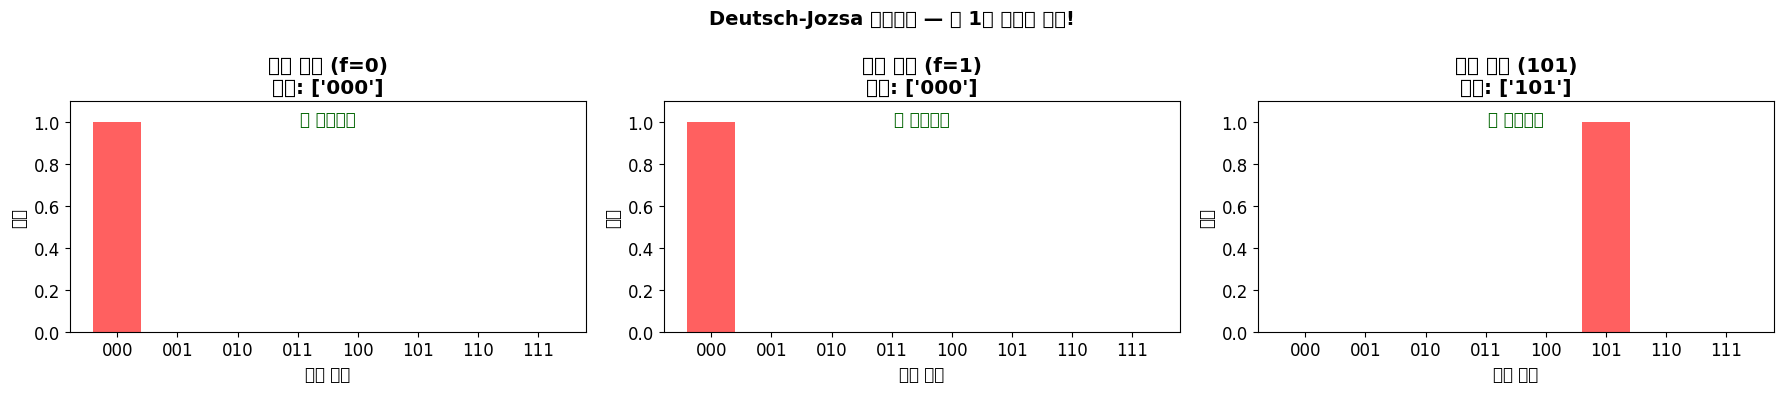

In [11]:
# ── 6-A. Deutsch-Jozsa 알고리즘 ──────────────────────────────────────────
def deutsch_jozsa(n: int, oracle_type: str = 'constant', secret: str = None):
    """
    n: 입력 큐비트 수
    oracle_type: 'constant_0', 'constant_1', 'balanced'
    secret: 균형 함수의 비밀 문자열 (기본값: '1'*n)
    """
    qc = QuantumCircuit(n+1, n, name=f"DJ-{oracle_type}")
    
    # 초기화: 보조 큐비트를 |1⟩로
    qc.x(n)
    qc.h(range(n+1))
    qc.barrier(label="Initialization")
    
    # 오라클
    if oracle_type == 'constant_0':
        pass  # f=0: 아무것도 안 함
    elif oracle_type == 'constant_1':
        qc.x(n)  # f=1: 보조 큐비트 반전
    else:  # balanced
        s = secret or '1' * n
        for i, bit in enumerate(reversed(s)):
            if bit == '1':
                qc.cx(i, n)
    
    qc.barrier(label="Oracle")
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

# n=3으로 시연
n_dj = 3
cases = [
    ('constant_0', "상수 함수 (f=0)"),
    ('constant_1', "상수 함수 (f=1)"),
    ('balanced',   "균형 함수 (101)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (otype, label) in zip(axes, cases):
    secret_s = '101' if 'balanced' in otype else None
    qc_dj = deutsch_jozsa(n_dj, otype, secret_s)
    result = sim.run(transpile(qc_dj, sim), shots=1024).result()
    counts = result.get_counts()
    
    all_states = [format(i, f'0{n_dj}b') for i in range(2**n_dj)]
    values = [counts.get(s, 0)/1024 for s in all_states]
    
    colors = ['#FF4444' if v > 0.5 else '#4488FF' for v in values]
    ax.bar(all_states, values, color=colors, alpha=0.85)
    ax.set_title(f'{label}\n결과: {list(counts.keys())}', fontweight='bold')
    ax.set_ylabel('확률'); ax.set_ylim(0, 1.1)
    ax.set_xlabel('측정 결과')
    verdict = "✅ 상수함수" if list(counts.keys()) == ['000'] else "✅ 균형함수"
    ax.text(0.5, 0.9, verdict, transform=ax.transAxes, ha='center',
            fontsize=12, fontweight='bold', color='darkgreen')

plt.suptitle("Deutsch-Jozsa 알고리즘 — 단 1회 쿼리로 판별!", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Deutsch-Jozsa 회로 (n=3, 균형 함수 101):


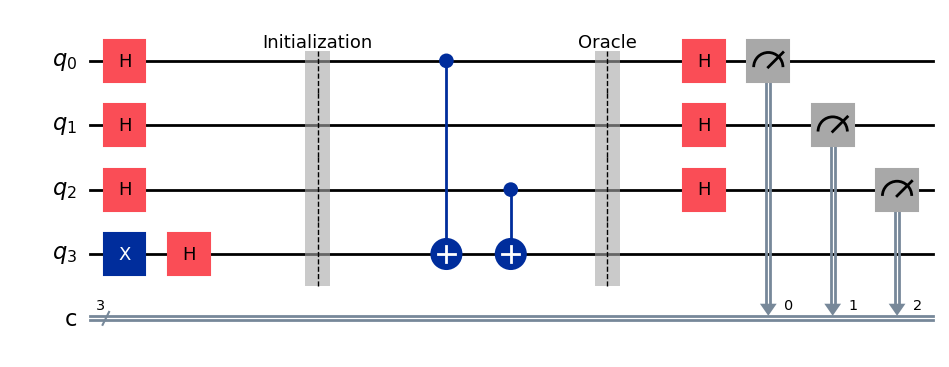


💡 해석:
  - 입력 상태를 중첩으로 → 오라클 1번 → 역 Hadamard
  - |000⟩: 상수함수 / 다른 결과: 균형함수
  - 고전적으로 최소 5번 쿼리 필요한 것을 1번에 해결!


In [12]:
# ── 8-B. 회로 시각화 ────────────────────────────────────────────────────
qc_dj_show = deutsch_jozsa(3, 'balanced', '101')
print("Deutsch-Jozsa 회로 (n=3, 균형 함수 101):")
display(qc_dj_show.draw('mpl', style='iqp'))

print("\n💡 해석:")
print("  - 입력 상태를 중첩으로 → 오라클 1번 → 역 Hadamard")
print("  - |000⟩: 상수함수 / 다른 결과: 균형함수")
print("  - 고전적으로 최소 5번 쿼리 필요한 것을 1번에 해결!")


## 9. Bernstein-Vazirani 알고리즘 

**문제**: f(x) = s·x (mod 2) 인 함수에서 비밀 문자열 s 찾기

**고전**: n번 쿼리 필요 (각 자리수 확인)  
**양자**: **단 1번** 쿼리로 s 전부 복원!

**원리**: Deutsch-Jozsa와 동일한 회로 구조  
- 측정 결과가 바로 s = 비밀 문자열

이는 **양자 병렬성(quantum parallelism)** 의 직관적 예시입니다.


/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/braket/ipykernel_78632/3068249388.py:39: UserWarning: Gly

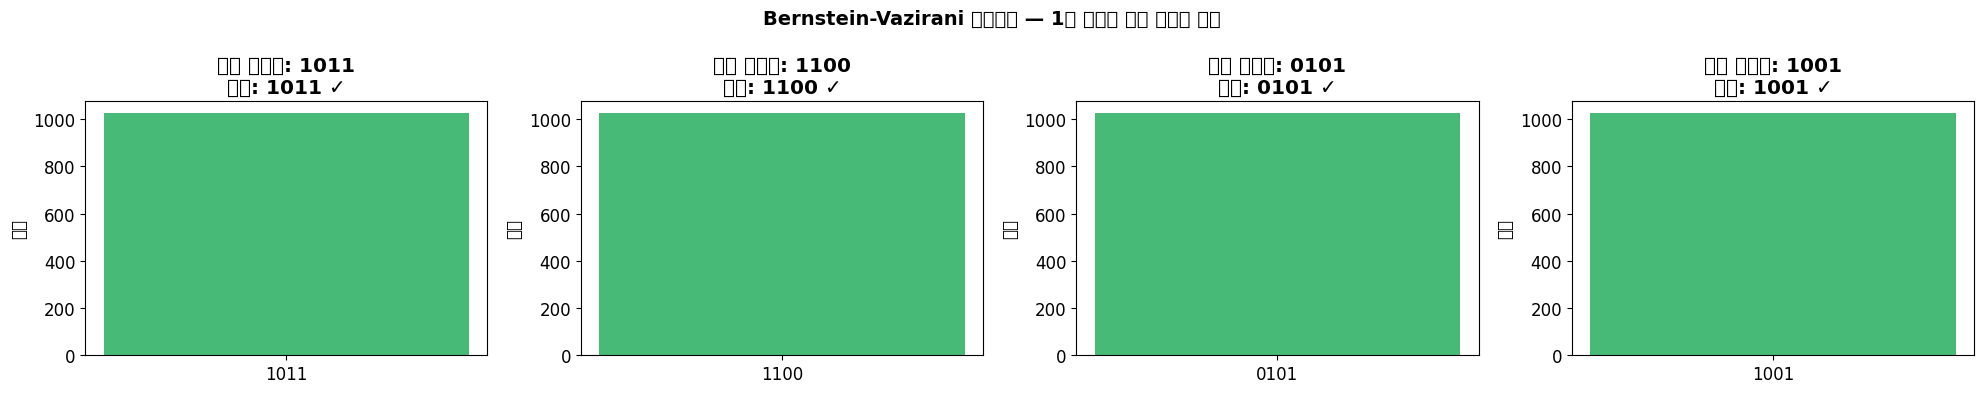

💡 항상 100% 확률로 비밀 문자열을 1회 만에 찾습니다!

회로 (비밀='1011'):


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWa

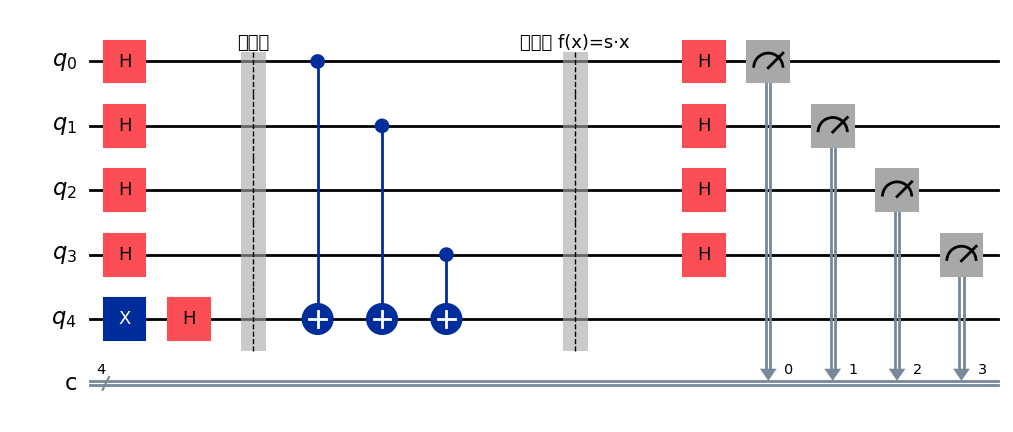

In [13]:
# ── 9. Bernstein-Vazirani 알고리즘 ──────────────────────────────────────
def bernstein_vazirani(secret: str) -> QuantumCircuit:
    n = len(secret)
    qc = QuantumCircuit(n+1, n, name=f"BV-{secret}")
    qc.x(n)
    qc.h(range(n+1))
    qc.barrier(label="초기화")
    
    # 오라클: f(x) = s·x
    for i, bit in enumerate(reversed(secret)):
        if bit == '1':
            qc.cx(i, n)
    qc.barrier(label="오라클 f(x)=s·x")
    
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

# 여러 비밀 문자열로 테스트
secrets = ['1011', '1100', '0101', '1001']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, secret in zip(axes, secrets):
    qc_bv = bernstein_vazirani(secret)
    result = sim.run(transpile(qc_bv, sim), shots=1024).result()
    counts = result.get_counts()
    
    found = max(counts, key=counts.get)
    correct = (found == secret)
    
    ax.bar(list(counts.keys()), list(counts.values()), 
           color='#27AE60' if correct else '#E74C3C', alpha=0.85)
    ax.set_title(f'비밀 문자열: {secret}\n발견: {found} {"✓" if correct else "✗"}',
                fontweight='bold')
    ax.set_ylabel('횟수')

plt.suptitle("Bernstein-Vazirani 알고리즘 — 1회 쿼리로 비밀 문자열 복원", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 항상 100% 확률로 비밀 문자열을 1회 만에 찾습니다!")

# 회로 시각화
print("\n회로 (비밀='1011'):")
display(bernstein_vazirani('1011').draw('mpl', style='iqp'))
